<a href="https://colab.research.google.com/github/KhenCahyo13/MyCampus-Jobsheet/blob/smt-5/pcvk/week-3/Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries & Define Initial Data

In [52]:
import cv2 as cv
import numpy as np
import glob
import os
from google.colab.patches import cv2_imshow

image_url = 'https://asset.kompas.com/crops/__wbPDdjsiDhfvS0lHSSp9Hpyig=/0x0:800x533/1200x800/data/photo/2021/09/19/614708b006de2.jpg'

# Practicum - Simple Image Operations

## Linier Brightness Transformation

In [ ]:
print('=== Change Brightness of Image ===')
print('==================================')

try:
  brightness = int(input('Input brightness value: '))
except ValueError:
  print('Invalid value')
  exit()

original_image = cv.imread('people.jpg')
brightness_image = np.zeros(original_image.shape, original_image.dtype)

# per pixels access
# for y in range(original_image.shape[0]):
#   for x in range(original_image.shape[1]):
#     for c in range(original_image.shape[2]):
#       brightness_image[y, x, c] = np.clip(original_image[y, x, c] + brightness, 0, 255)

# Simple ways without loop
brightness_image = cv.convertScaleAbs(original_image, beta=brightness)

final_lbt_frame = cv.hconcat((original_image, brightness_image))
cv2_imshow(final_lbt_frame)

# Task - Simple Image Operations

## Number 1 - Inverse Image

In [ ]:
original_image = cv.imread('people.jpg')
inversed_image = 255 - original_image

final_inverse_frame = cv.hconcat((original_image, inversed_image))
cv2_imshow(final_inverse_frame)

## Number 2 - Contrast

In [ ]:
original_image = cv.imread('people.jpg')
contrast_image = np.zeros(original_image.shape, original_image.dtype);

print('=== Change Contrast of Image ===')
print('==================================')

try:
  brightness = int(input('Input brightness value (-255 - 255): '))
  contrast = int(input('Input contrast value (1 - 3): '))
except ValueError:
  print('Invalid value')
  exit()

contrast_image = contrast * original_image.astype(np.float32) + brightness
contrast_image = np.clip(contrast_image, 0, 255).astype(np.uint8)

# Simple ways without raw formula
# contrast_image = cv.convertScaleAbs(original_image, alpha=contrast, beta=brightness)

final_contrast_frame = cv.hconcat((original_image, contrast_image))
cv2_imshow(final_contrast_frame)

## Number 3 - Logarithmic Brightness

In [ ]:
original_image = cv.imread('people.jpg')
logarithmic_image = np.zeros(original_image.shape, original_image.dtype);

print('=== Change Brightness of Image (Logarithmic) ===')
print('==================================')

try:
  brightness = int(input('Input brightness value: '))
except ValueError:
  print('Invalid value')
  exit()

logarithmic_image = brightness * np.log(1 + original_image.astype(np.float32))
logarithmic_image = np.clip(logarithmic_image, 0, 255).astype(np.uint8)

final_logarithmic_frame = cv.hconcat((original_image, logarithmic_image))
cv2_imshow(final_logarithmic_frame)

## Number 4 - Grayscale

In [ ]:
# Averaging Grayscale
original_image = cv.imread('people.jpg')
B, G, R = cv.split(original_image)
ag_image = np.zeros(original_image.shape, original_image.dtype);

ag_image = ((R.astype(np.float32) + G.astype(np.float32) + B.astype(np.float32)) / 3)
ag_image = np.clip(ag_image, 0, 255).astype(np.uint8)

ag_image_bgr = cv.cvtColor(ag_image, cv.COLOR_GRAY2BGR)

final_ag_frame = cv.hconcat((original_image, ag_image_bgr))
cv2_imshow(final_ag_frame)

(b, g, r) = ag_image_bgr[10, 20] # Get the pixels value on the row 10 column 20
print("B =", b, "G =", g, "R =", r)

In [ ]:
# Lightness Grayscale
original_image = cv.imread('people.jpg')
B, G, R = cv.split(original_image)
lg_image = np.zeros(original_image.shape, original_image.dtype);

max_val = np.maximum(np.maximum(R, G), B)
min_val = np.minimum(np.minimum(R, G), B)

lg_image = ((max_val.astype(np.float32) + min_val.astype(np.float32)) / 2)
lg_image = np.clip(lg_image, 0, 255).astype(np.uint8)

lg_image_bgr = cv.cvtColor(lg_image, cv.COLOR_GRAY2BGR)

final_lg_frame = cv.hconcat((original_image, lg_image_bgr))
cv2_imshow(final_lg_frame)

(b, g, r) = lg_image_bgr[10, 20] # Get the pixels value on the row 10 column 20
print("B =", b, "G =", g, "R =", r)

In [ ]:
# Luminate Grayscale
original_image = cv.imread('people.jpg')
B, G, R = cv.split(original_image)
lum_image = np.zeros(original_image.shape, original_image.dtype);

lum_image = (0.21 * R.astype(np.float32)) + (0.72 * G.astype(np.float32)) + (0.07 * B.astype(np.float32))
lum_image = np.clip(lum_image, 0, 255).astype(np.uint8)

lum_image_bgr = cv.cvtColor(lum_image, cv.COLOR_GRAY2BGR)

final_lum_frame = cv.hconcat((original_image, lum_image_bgr))
cv2_imshow(final_lum_frame)

(b, g, r) = lum_image_bgr[10, 20] # Get the pixels value on the row 10 column 20
print("B =", b, "G =", g, "R =", r)

## Number 5 - Convert other colors to Grayscale

In [ ]:
original_image = cv.imread('people.jpg')
converted_to_gray_image = original_image.copy()
hsv = cv.cvtColor(original_image, cv.COLOR_BGR2HSV)

lower_blue = np.array([100, 50, 50])
upper_blue = np.array([140, 255, 255])

mask = cv.inRange(hsv, lower_blue, upper_blue)
blue_part = cv.bitwise_and(original_image, original_image, mask=mask)

gray = cv.cvtColor(converted_to_gray_image, cv.COLOR_BGR2GRAY)
gray_bgr = cv.cvtColor(gray, cv.COLOR_GRAY2BGR)
gray_bgr_converted = np.where(blue_part != 0, original_image, gray_bgr)

final_cvt_frame = cv.hconcat((original_image, gray_bgr_converted))
cv2_imshow(final_cvt_frame)

# Task - Arithmetic and Logical Operations

## Number 1 - Gamma Correction

In [ ]:
print('=== Gamma Correction ===')
print('========================')

try:
  gamma = float(input('Enter gamma value: '))
except ValueError:
  print('Invalid value')

def adjust_gamma(image, gamma=1.0):
    table = np.array([(i / 255.0) ** gamma * 255 for i in np.arange(256)]).astype("uint8")
    return cv.LUT(image, table)

original_image = cv.imread('people.jpg')
gamma_image = adjust_gamma(original_image, gamma)

final_gamma_frame = cv.hconcat((original_image, gamma_image))
cv2_imshow(final_gamma_frame)

## Number 2 - Image Depth

In [ ]:
bit_depth = 2
levels = 2 ** bit_depth
step = 255 / (levels - 1)

original_image = cv.imread('people.jpg')

depth_image = np.round(original_image / step) * step
depth_image = np.clip(depth_image, 0, 255).astype(np.uint8)

final_depth_frame = cv.hconcat((original_image, depth_image))
cv2_imshow(final_depth_frame)

## Number 3 - Average Denoising

In [ ]:
# Mount the images
folder_path = "/content/drive/MyDrive/Collage/Semester 5/PCVK/Dataset/noises/"
image_paths = sorted(glob.glob(os.path.join(folder_path, "*.jpg")))

print('Total of found images: ', len(image_paths))

# Define PSNR function
def PSNR(img1, img2):
  mse = np.mean((img1 - img2) ** 2)

  if (mse == 0):
    return 100

  max_pixel = 255.0
  psnr = 20 * np.log10(max_pixel / np.sqrt(mse))
  return psnr

In [ ]:
# Image Execution
selected_paths = image_paths[0:10] # Just change 10 with needed number based on total images
images = [cv.imread(p) for p in selected_paths]

denoised_image = np.mean(images, axis=0).astype(np.uint8)

# PSNR Evaluation
reference = images[0]
psnr_before = PSNR(reference, images[1]) # before denoising (noisy vs other noisy)
psnr_after = PSNR(reference, denoised_image) # after denoising

final_denoised_frame = cv.hconcat((reference, denoised_image))
cv2_imshow(final_denoised_frame)

print(f"\nPSNR before denoising: {psnr_before:.2f} dB")
print(f"PSNR after denoising: {psnr_after:.2f} dB")

## Number 4 - Image Masking

In [95]:
# Setup Initial Images
original_image = cv.imread('people.jpg')
mask_image = np.zeros(original_image.shape, original_image.dtype)
mask_image = cv.circle(mask_image, (700, 450), 300, (255, 255, 255), -1) # Create 1 circle on the mask_image

# frame_masked_images = cv.hconcat((original_image, mask_image))
# cv2_imshow(frame_masked_images)

In [ ]:
# NOT Operator
not_masked_image = cv.bitwise_not(original_image, mask_image)

frame_not_masked_images = cv.hconcat((original_image, not_masked_image))
cv2_imshow(frame_not_masked_images)

In [ ]:
# OR Operator
or_masked_image = cv.bitwise_or(original_image, mask_image)

frame_or_masked_images = cv.hconcat((original_image, or_masked_image))
cv2_imshow(frame_or_masked_images)

In [ ]:
# AND Operator
and_masked_image = cv.bitwise_and(original_image, mask_image)

frame_and_masked_images = cv.hconcat((original_image, and_masked_image))
cv2_imshow(frame_and_masked_images)

In [ ]:
# NAND Operator
nand_masked_image = cv.bitwise_not(cv.bitwise_and(original_image, mask_image))

frame_nand_masked_images = cv.hconcat((original_image, nand_masked_image))
cv2_imshow(frame_nand_masked_images)

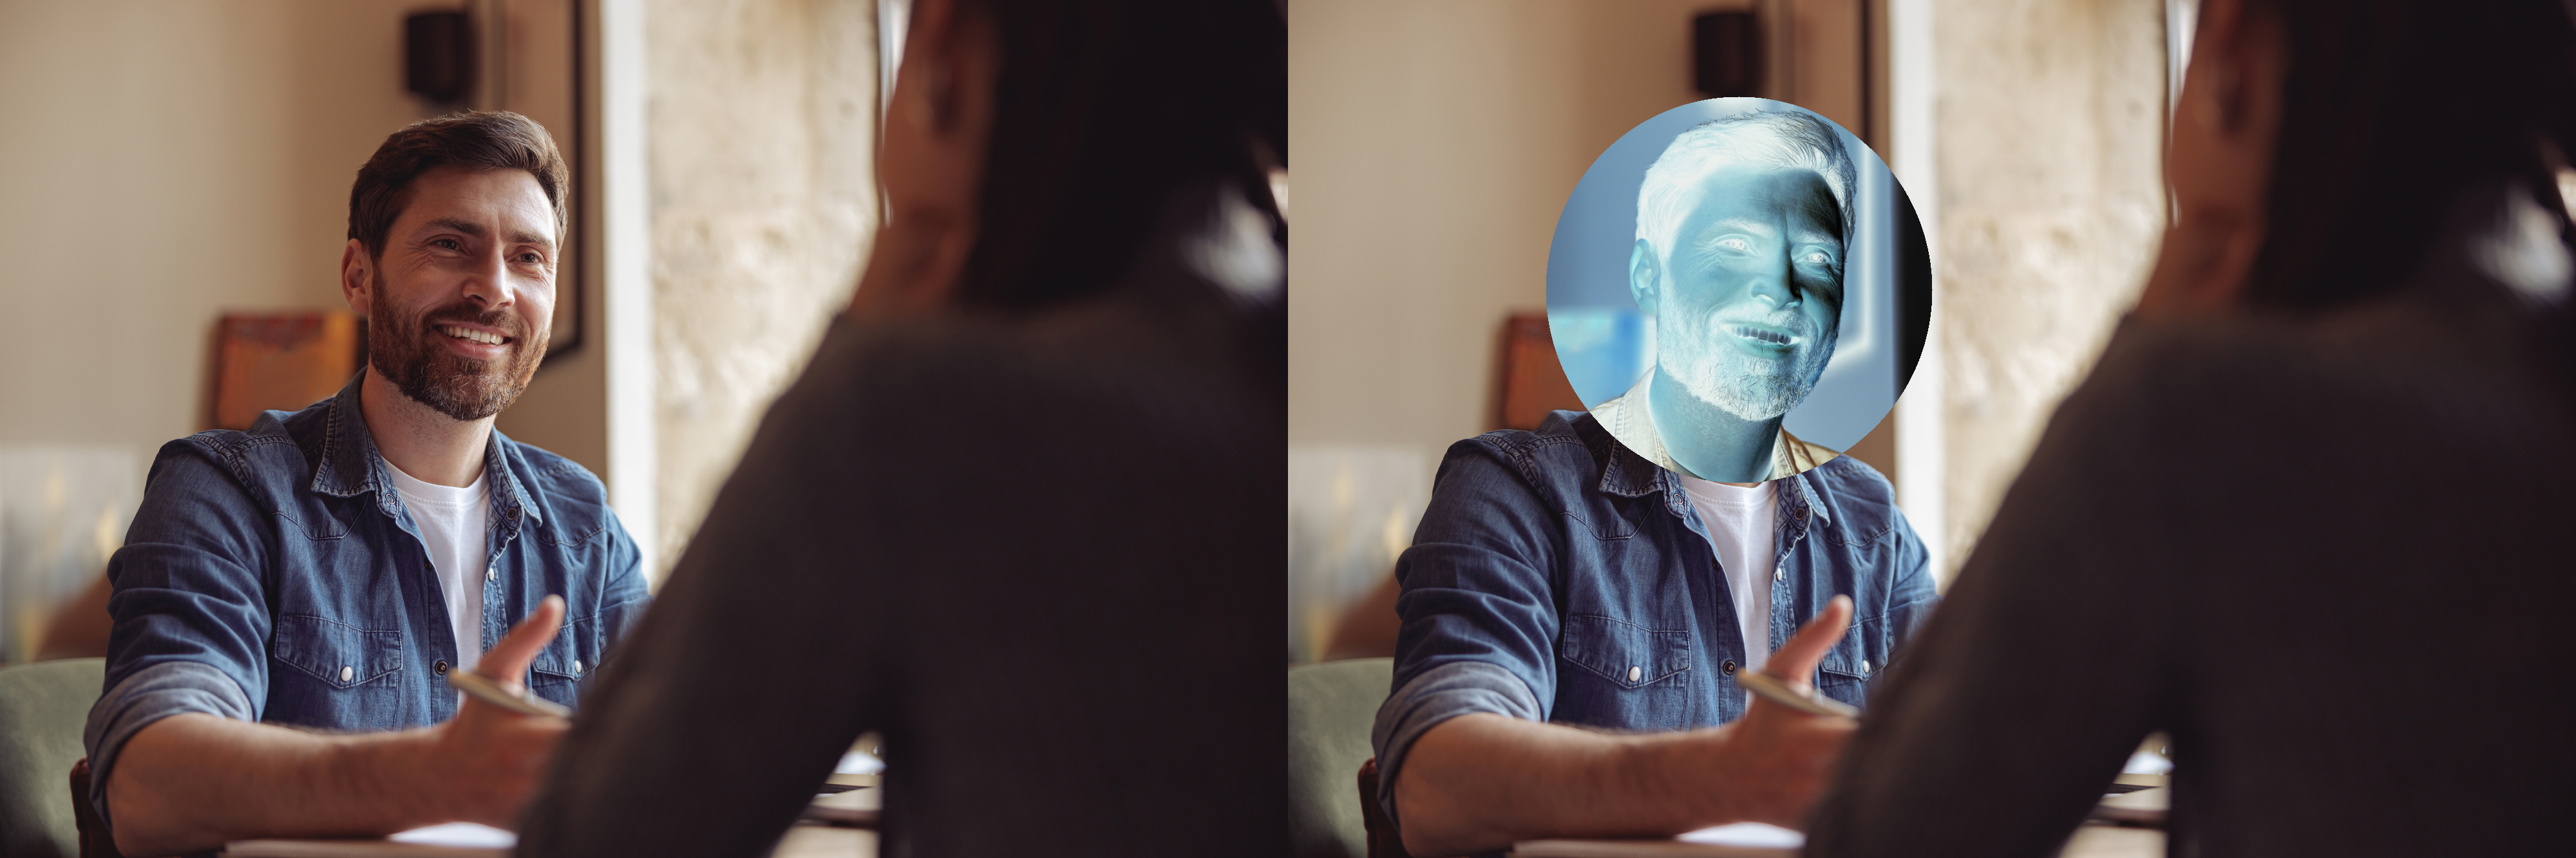

In [96]:
# XOR Operator
xor_masked_image = cv.bitwise_xor(original_image, mask_image)

frame_xor_masked_images = cv.hconcat((original_image, xor_masked_image))
cv2_imshow(frame_xor_masked_images)